In [1]:
from pathlib import Path
import os
from tqdm import tqdm
import re

In [2]:
from src.utils.helpers import get_project_utilities_env

In [3]:
from src.dataloading.epiconfig import EpiConfig
from src.dataloading.epidataorchestration import EpiDataOrchestrator

BASE_CONFIG = dict(
    disease              = 'influenza',
    country              = 'germany',
    level                = 'nuts2',
    min_date             = '2012-06-01',
    max_date             = '2020-06-01',
    feature_popsize      = False,
    feature_popdens      = True,
    feature_gisd         = False,
    feature_popage       = False,
    feature_kreise_classes = False,
    feature_borders      = False,
    sequence_length      = 4,
    normalization_method = 'zscore',
    log_transform        = ['incidence'],
)

horizons = range(1,8)

dataorchestrators = {}

for hl in tqdm(horizons):
    cfg = EpiConfig(horizon_leadtime=hl, **BASE_CONFIG)
    dataorchestrators[hl] = EpiDataOrchestrator(cfg).build()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:10<00:00,  1.54s/it]


In [4]:
from src.dataloading.dataloaders import (
    BaseLineDataLoaderManager, DeepDataLoaderManager, GraphDataLoaderManager
)
from src.models.deep.deepmodel import DeepModel
from src.models import ClimateologyModel, ClimaScaleModel, PersistenceModel
from src.evaluation import Evaluator
import pandas as pd

GRAPH_KEYS = {
    'identity' : 'graph1',
    'geo'      : 'graph2',
    'random'   : 'graph3',
    'commuter' : 'graph16',
}

def parse_model_filename(filename: str) -> dict:
    """
    Parse model filename into components.
    Expected format: {model_type}_{graph?}_hl{hl}_s{seed}.pt
    Examples:
        lstm_hl1_s42.pt
        gcn_geo_hl1_s42.pt
        gcnlstm_identity_hl3_s123.pt
        gatv2lstm_random_hl5_s456.pt
    """
    name = filename.replace('.pt', '')

    hl_match   = re.search(r'_hl(\d+)', name)
    seed_match = re.search(r'_s(\d+)$', name)

    if not hl_match or not seed_match:
        raise ValueError(f"Cannot parse filename: {filename}")

    hl   = int(hl_match.group(1))
    seed = int(seed_match.group(1))

    # strip hl and seed suffix to get model+graph prefix
    prefix = re.sub(r'_hl\d+_s\d+$', '', name)

    # determine graph key
    graph_key = None
    for gname in GRAPH_KEYS:
        if prefix.endswith(f'_{gname}'):
            graph_key = gname
            prefix    = prefix[:-(len(gname) + 1)]  # strip graph name
            break

    model_type = prefix  # what remains is the model type: lstm, gcn, gcnlstm, gatv2lstm

    return {
        'model_type': model_type,
        'graph_key' : graph_key,
        'hl'        : hl,
        'seed'      : seed,
        'name'      : name,
    }


def build_dataloader(model_type: str, graph_key: str, data_orch):
    """Build the correct dataloader for a given model type and graph key."""
    if model_type == 'lstm':
        return DeepDataLoaderManager(data_orch).build()

    elif model_type in ('gcn', 'gcnlstm', 'gatv2lstm'):
        if graph_key is None:
            raise ValueError(f"Model type '{model_type}' requires a graph_key")
        graph_id = GRAPH_KEYS[graph_key]
        return (GraphDataLoaderManager(data_orch)
                .retrieve_static_graph(graph_id)
                .build())
    else:
        raise ValueError(f"Unknown model type: {model_type}")


def load_models_for_horizon(
    abs_directory:    Path,
    hl:               int,
    data_orch,
    seeds:            list = None,
    model_types:      list = None,
) -> list:
    """
    Load all saved models for a given horizon from abs_directory.
    Returns list of loaded DeepModel instances ready for forecast().
    """
    hl_files = [
        f for f in os.listdir(abs_directory)
        if f.endswith('.pt') and f'_hl{hl}_' in f
    ]

    loaded_models = []

    for filename in hl_files:
        try:
            info = parse_model_filename(filename)
        except ValueError as e:
            print(f"  skipping {filename}: {e}")
            continue

        # filter by seed if specified
        if seeds is not None and info['seed'] not in seeds:
            continue

        # filter by model type if specified
        if model_types is not None and info['model_type'] not in model_types:
            continue

        try:
            dlm   = build_dataloader(info['model_type'], info['graph_key'], data_orch)
            model = DeepModel.load(
                model_name        = info['name'],
                subdir            = str(abs_directory.name),
                dataloadermanager = dlm,
            )
            loaded_models.append(model)
            # print(f"  ✓ {filename}")

        except Exception as e:
            print(f"  ✗ {filename}: {e}")

    return loaded_models


# ── usage ─────────────────────────────────────────────────────────────────

experiment_dir = 'experiment_1_v2'
abs_directory  = Path(get_project_utilities_env()) / 'models' / experiment_dir

all_metrics = []

for hl in tqdm(range(1, 8), desc='horizons'):
    data_orch = dataorchestrators[hl]

    # baselines
    baseline_dlm = BaseLineDataLoaderManager(data_orch)
    persistence  = PersistenceModel(baseline_dlm,  f'persistence_hl{hl}')
    climatology  = ClimateologyModel(baseline_dlm, f'climateology_hl{hl}')
    climascale   = ClimaScaleModel(baseline_dlm,   f'climascale_hl{hl}')
    persistence.forecast('test')
    climatology.forecast('test')
    climascale.forecast('test')
    baselines = [persistence, climatology, climascale]

    # load deep models
    # print(f"\nhl={hl}: loading models...")
    deep_models = load_models_for_horizon(
        abs_directory = abs_directory,
        hl            = hl,
        data_orch     = data_orch,
    )

    if not deep_models:
        print(f"  no models found for hl={hl}")
        continue

    # forecast
    for model in deep_models:
        model.forecast('test')

    # evaluate
    all_models = baselines + deep_models
    evaluator  = Evaluator(all_models)
    evaluator.add_evaluation(horizon=0, dataset='test')

    # extract metrics
    metrics            = evaluator.data_compilation.get_data(0, 'test')['metrics'].copy()
    metrics['horizon'] = hl
    metrics['seed']    = metrics['model'].astype(str).str.extract(r'_s(\d+)$')[0].astype(float)
    metrics['model']   = (metrics['model']
                          .astype(str)
                          .str.replace(f'_hl{hl}_s\\d+', '', regex=True)
                          .str.replace(f'_hl{hl}', '', regex=False))

    all_metrics.append(metrics)

    del evaluator, deep_models, all_models, data_orch
    # print(f"  hl={hl} done")

metrics_df = pd.concat(all_metrics, ignore_index=True)
print(f"\nDone. Total records: {len(metrics_df)}")

METRICS = metrics_df.copy()

horizons: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [01:07<00:00,  9.63s/it]


Done. Total records: 9956


In [5]:
def aggregate_seeds(metrics_df: pd.DataFrame, 
                    metrics:    list = ['ccc', 'rmse', 'mae', 'mda','r2','mape']) -> pd.DataFrame:
    """
    Average metrics across seeds per node per model per horizon.
    Returns one row per (horizon, model, node).
    """
    available = [m for m in metrics if m in metrics_df.columns]
    
    agg = (metrics_df
              .groupby(['horizon', 'model', 'node'])[available]
              .mean()
              .reset_index())
    
    return agg

# aggregate
metrics_agg = aggregate_seeds(metrics_df)

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

def plot_graphstructure_advantage(model1: str, model2: str, metric: str):

    # ccc difference between gcn-identiy and gcn-geo
    gcn_spatial = metrics_agg.copy()
    gcn_spatial = gcn_spatial[gcn_spatial['model'].isin([model1,model2])]
    gcn_spatial = gcn_spatial.pivot_table(
        index=['horizon','node'], columns='model', values=metric
    ).round(4).reset_index(drop = False)
    gcn_spatial['diff'] = 100* (gcn_spatial[model1] - gcn_spatial[model2]) / gcn_spatial[model2]

    # compute mean and std of % diff across nodes per horizon
    gap_summary = (gcn_spatial
                .groupby('horizon')['diff']
                .agg(mean='mean', std='std', 
                        ci95=lambda x: 1.96 * x.std() / np.sqrt(len(x)))
                .reset_index())

    fig, ax = plt.subplots(figsize=(10, 4))

    ylabel  = f'% {metric} of {model2}'
    title   = f'Relative {metric} advantage across forecast horizons: {model1} vs {model2}'


    ax.errorbar(
        x          = gap_summary['horizon'],
        y          = gap_summary['mean'],
        yerr       = gap_summary['ci95'],   # swap to 'std' if you prefer std
        fmt        = 'o',
        capsize     = 5,
        capthick    = 1.5,
        linewidth   = 1.5,
        markersize  = 7,
        color       = '#2196F3',
        label      = 'mean ± 95% CI across nodes'
    )

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5,
               label=f'{model1} = {model2}')
    ax.set_xlabel('Forecast horizon (weeks ahead)', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    # ax.set_yscale('log')
    plt.tight_layout()
    plt.show()

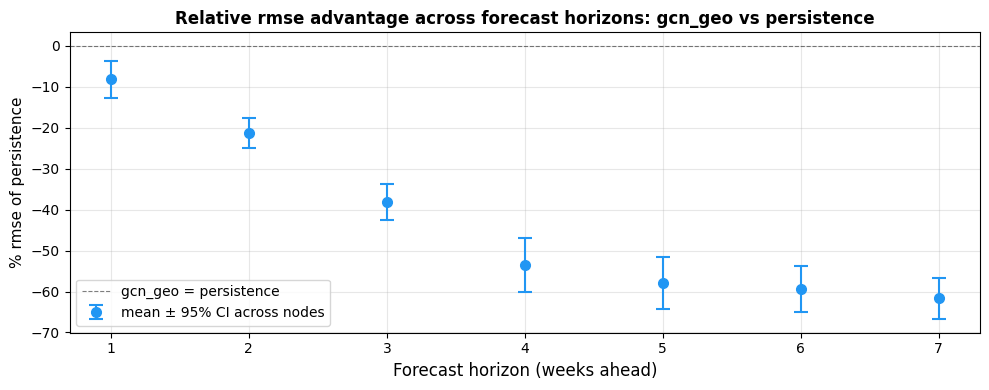

In [37]:
plot_graphstructure_advantage('gcn_geo', 'persistence','rmse')